# Level 3 Task 1: Predictive Modeling (Classification)

# 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# 2. Load Dataset

In [3]:
df = pd.read_csv("C:/Users/dhine/Downloads/churn-bigml-80.csv")
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


# 3. Data Preprocessing

### Handle Categorical Variables 

In [4]:
# Convert categorical columns using Label Encoding
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

### Define Features & Target

In [5]:
X = df.drop("Churn", axis=1)   # target column
y = df["Churn"]

### Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
X_train.shape, X_test.shape

((2132, 19), (534, 19))

### Feature Scaling

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Train Models

### Logistic Regression

In [9]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Decision Tree

In [10]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

### Random Forest

In [11]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# 5. Evaluation Function

In [12]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"----- {model_name} -----")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("\n")

### Evaluate All Models

In [13]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, "Random Forest")

----- Logistic Regression -----
Accuracy: 0.8595505617977528
Precision: 0.5625
Recall: 0.22784810126582278
F1 Score: 0.32432432432432434


----- Decision Tree -----
Accuracy: 0.898876404494382
Precision: 0.6811594202898551
Recall: 0.5949367088607594
F1 Score: 0.6351351351351351


----- Random Forest -----
Accuracy: 0.947565543071161
Precision: 0.9811320754716981
Recall: 0.6582278481012658
F1 Score: 0.7878787878787878




# 6. Hyperparameter Tuning (Grid Search)

### Random Forest (Best Model Usually)

In [14]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


### Best Model PredictionBest Model PredictionBest Model Prediction

In [15]:
best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test)

evaluate_model(y_test, y_pred_best, "Tuned Random Forest")

----- Tuned Random Forest -----
Accuracy: 0.951310861423221
Precision: 0.9818181818181818
Recall: 0.6835443037974683
F1 Score: 0.8059701492537313




# 7. Model Comparison

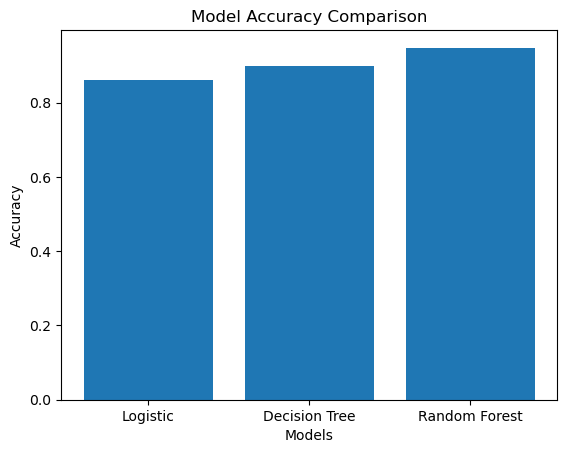

In [16]:
models = ['Logistic', 'Decision Tree', 'Random Forest']
accuracy = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

# Conclusion

#### “I built a classification model to predict customer churn. I performed preprocessing including encoding and scaling, trained multiple models like Logistic Regression, Decision Tree, and Random Forest, and evaluated them using accuracy, precision, recall, and F1-score. I further improved performance using GridSearchCV for hyperparameter tuning, where Random Forest performed the best.”